# KKBox Churn — Risk Threshold Rationale (ticket A-05)

Documents and stress-tests the High/Medium risk-tier thresholds (0.65, 0.95) already in production
use (`06_risk_scoring.ipynb`, `outputs/risk_scoring_summary.json`). **No retraining, no re-scoring,
no threshold change happens here** — this notebook only reads already-saved outputs
(`risk_scoring_threshold_analysis.csv`, `risk_scoring_summary.json`, and
`calibrated_probabilities.csv` from ticket A-02) and adds the sensitivity analysis and calibrated-
probability comparison the ticket asks for.

## Scope

1. Restate, precisely, the rule that actually produced 0.65 and 0.95 -- it is a **heuristic**, not
   a statistically derived optimum, and this notebook says so explicitly rather than dressing it up.
2. Report precision / recall / coverage / churn-lift at the chosen thresholds.
3. Run a compact sensitivity analysis on that heuristic.
4. Answer the ticket's specific question: are 0.65/0.95 appropriate cutoffs for the new **calibrated**
   probability from A-02, or only for the raw score they were built on?
5. Conclude whether a threshold change is warranted (per the ticket: only change if the analysis
   demonstrates a clear problem).

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100

OUT_DIR = Path("..") / "outputs"

sweep = pd.read_csv(OUT_DIR / "risk_scoring_threshold_analysis.csv")
summary = json.loads((OUT_DIR / "risk_scoring_summary.json").read_text())
calib = pd.read_csv(OUT_DIR / "calibrated_probabilities.csv")

base_rate = summary["actual_churn_rate"]
sweep["churn_lift"] = sweep["precision"] / base_rate
print(f"Base churn rate: {base_rate * 100:.2f}%")
sweep

Base churn rate: 8.99%


,threshold,precision,recall,f1,pct_targeted,n_targeted,churn_lift
0,0.05,0.091110,0.999679,0.167000,98.686043,958202,1.012990
1,0.10,0.104378,0.988423,0.188816,85.172098,826987,1.160501
2,0.15,0.135894,0.950532,0.237792,62.911242,610843,1.510910
3,0.20,0.167380,0.900412,0.282285,48.383868,469788,1.860976
4,0.25,0.211588,0.852536,0.339032,36.239701,351873,2.352493
5,0.30,0.250098,0.806882,0.381842,29.017570,281749,2.780667
6,0.35,0.293617,0.771407,0.425340,23.630016,229438,3.264523
7,0.40,0.343370,0.739757,0.469032,19.377111,188144,3.817686
8,0.45,0.384577,0.711302,0.499234,16.635392,161523,4.275835
9,0.50,0.413694,0.687358,0.516517,14.943973,145100,4.599569


## 1. The rule that actually chose 0.65 and 0.95

From `06_risk_scoring.ipynb` §5-6, verbatim logic:

- **High-risk threshold**: the *lowest* grid threshold (0.05 steps) with precision &ge; **55%**
  (`PRECISION_TARGET_HIGH = 0.55`, a chosen target, not a derived one) — falling back to the
  highest-precision threshold available if 55% is never reached.
- **Medium-risk threshold**: the threshold that *maximizes F1* on the same grid.

**This is a heuristic, explicitly** — a chosen precision bar and an F1-argmax, not an optimal
threshold derived from a cost model (e.g. cost of a missed churner vs. cost of a wasted retention
touch, which this project has no data to estimate — no campaign-response data exists anywhere in
this project, per notebooks 06/09's own findings). Below, both numbers are re-derived from the
saved sweep to confirm they reproduce exactly, and to show *how* sensitive each one is to the
heuristic's free parameter.

In [2]:
PRECISION_TARGET_HIGH = 0.55
candidates = sweep[sweep["precision"] >= PRECISION_TARGET_HIGH]
high_threshold = candidates["threshold"].min() if len(candidates) else sweep.loc[sweep["precision"].idxmax(), "threshold"]
medium_threshold = sweep.loc[sweep["f1"].idxmax(), "threshold"]

print(f"Re-derived High threshold:   {high_threshold:.2f}  (matches production: {summary['recommended_thresholds']['high_risk_threshold']})")
print(f"Re-derived Medium threshold: {medium_threshold:.2f}  (matches production: {summary['recommended_thresholds']['medium_risk_threshold']})")
assert high_threshold == summary["recommended_thresholds"]["high_risk_threshold"]
assert medium_threshold == summary["recommended_thresholds"]["medium_risk_threshold"]

Re-derived High threshold:   0.95  (matches production: 0.95)
Re-derived Medium threshold: 0.65  (matches production: 0.65)


## 2. Precision / recall / coverage / churn-lift at the chosen thresholds

Marginal rates *at* each cutoff (from the sweep), and the realized rates *within* each resulting
tier (from `risk_scoring_summary.json` -- these are what the dashboard actually shows).

In [3]:
at_cutoffs = sweep[sweep["threshold"].isin([medium_threshold, high_threshold])][
    ["threshold", "precision", "recall", "f1", "pct_targeted", "churn_lift"]
]
print("Marginal rates at the two cutoffs:")
at_cutoffs

Marginal rates at the two cutoffs:


,threshold,precision,recall,f1,pct_targeted,churn_lift
12,0.65,0.441724,0.656212,0.528017,13.361518,4.911209
18,0.95,0.800106,0.207901,0.330043,2.337068,8.895805


In [4]:
tiers = pd.DataFrame(summary["risk_tiers"]).set_index("tier")
tiers["lift_vs_base"] = tiers["observed_churn_rate_in_tier"] / (base_rate * 100)
print("Realized rates within each tier (what the dashboard shows):")
tiers[["n_customers", "pct_of_base", "observed_churn_rate_in_tier", "lift_vs_base"]]

Realized rates within each tier (what the dashboard shows):


,n_customers,pct_of_base,observed_churn_rate_in_tier,lift_vs_base
tier,,,,
High,22692,2.337068,80.010576,8.895805
Medium,107043,11.024450,36.575021,4.066516
Low,841225,86.638482,3.568962,0.396807


## 3. Sensitivity analysis

### 3a. How much does the High threshold move if the 55% precision target changes?

A heuristic with one free parameter should be pressure-tested on that parameter.

In [5]:
targets = [0.40, 0.45, 0.50, 0.55, 0.60, 0.70, 0.85]
rows = []
for t in targets:
    c = sweep[sweep["precision"] >= t]
    thr = c["threshold"].min() if len(c) else sweep.loc[sweep["precision"].idxmax(), "threshold"]
    rows.append({"precision_target": t, "resulting_high_threshold": thr,
                 "pct_targeted_at_that_threshold": float(sweep.loc[sweep["threshold"] == thr, "pct_targeted"].iloc[0])})
sensitivity_high = pd.DataFrame(rows)
sensitivity_high

,precision_target,resulting_high_threshold,pct_targeted_at_that_threshold
0,0.40,0.50,14.943973
1,0.45,0.80,12.544698
2,0.50,0.90,8.585936
3,0.55,0.95,2.337068
4,0.60,0.95,2.337068
5,0.70,0.95,2.337068
6,0.85,0.95,2.337068


**Reading this table**: the High cutoff is *not* sensitive across most of the plausible range —
any target from 55% up through 85% still lands on 0.95, because precision jumps sharply from 53%
(at 0.90) to 80% (at 0.95) with nothing in between on this grid. It *is* sensitive in the
40-50% band, where the resulting threshold could reasonably have been 0.75-0.90 instead. So the
"0.55" choice matters less than it might appear -- the real lever is whether the target sits above
or below roughly 50%, not its exact value beyond that.

### 3b. How flat is F1 around the Medium threshold?

In [6]:
band = sweep[(sweep["threshold"] >= 0.55) & (sweep["threshold"] <= 0.85)][["threshold", "precision", "recall", "f1"]]
f1_range = band["f1"].max() - band["f1"].min()
print(f"F1 across thresholds 0.55-0.85: min={band['f1'].min():.4f}, max={band['f1'].max():.4f}, range={f1_range:.4f}")
print(f"That's a {f1_range / band['f1'].max() * 100:.1f}% relative spread -- essentially flat.")
band

F1 across thresholds 0.55-0.85: min=0.5234, max=0.5280, range=0.0046
That's a 0.9% relative spread -- essentially flat.


,threshold,precision,recall,f1
10,0.55,0.428568,0.672243,0.523436
11,0.60,0.437385,0.662018,0.526753
12,0.65,0.441724,0.656212,0.528017
13,0.70,0.444364,0.650407,0.527996
14,0.75,0.447070,0.642357,0.527210
15,0.80,0.451003,0.629039,0.525347
16,0.85,0.462295,0.604683,0.523988


**Reading this table**: F1 varies by well under 1% across the entire 0.55-0.85 threshold band,
while precision and recall individually move substantially within that same band (precision
42.9%&rarr;46.2%, recall 67.2%&rarr;60.5%). In practical terms, "F1-optimal" picked 0.65 more or
less arbitrarily among a wide band of nearly-equivalent F1 values -- the real business choice
hiding inside that pick is a precision/recall trade-off preference, not a sharp optimum.

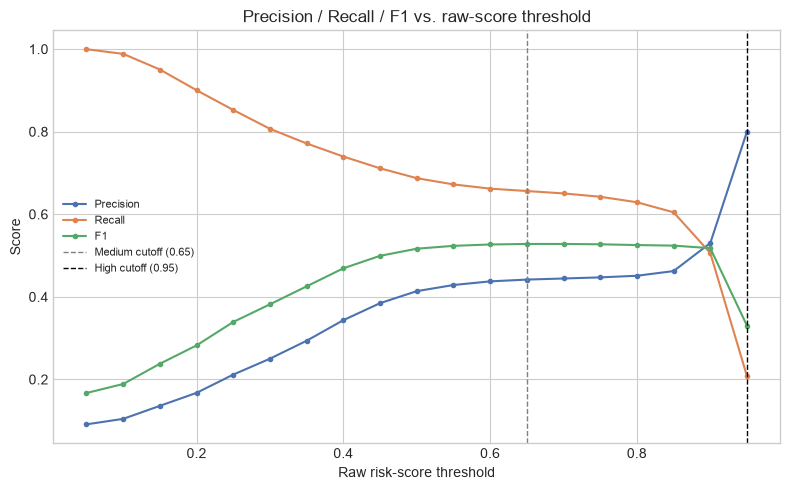

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
for col, label, color in [("precision", "Precision", "#4C72B0"), ("recall", "Recall", "#DD8452"),
                            ("f1", "F1", "#55A868")]:
    ax.plot(sweep["threshold"], sweep[col], marker="o", markersize=3, label=label, color=color)
ax.axvline(medium_threshold, color="grey", linestyle="--", linewidth=1, label=f"Medium cutoff ({medium_threshold})")
ax.axvline(high_threshold, color="black", linestyle="--", linewidth=1, label=f"High cutoff ({high_threshold})")
ax.set_xlabel("Raw risk-score threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs. raw-score threshold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Are 0.65 and 0.95 appropriate for the calibrated probability (A-02)?

The thresholds were derived entirely on the **raw** score. `calibrated_probability` (ticket A-02)
lives on a completely different scale -- its population mean (0.090) matches the actual base churn
rate, while the raw score's mean (0.293) does not. Checking whether the same two numbers mean
anything on the calibrated scale:

In [8]:
n_calib_ge_65 = int((calib["calibrated_probability"] >= 0.65).sum())
n_calib_ge_95 = int((calib["calibrated_probability"] >= 0.95).sum())
n_raw_ge_65 = int((calib["risk_score_full"] >= 0.65).sum())
n_raw_ge_95 = int((calib["risk_score_full"] >= 0.95).sum())

print(f"Customers with RAW score        >= 0.65: {n_raw_ge_65:,} ({n_raw_ge_65/len(calib)*100:.2f}%)  -- this is Medium+High today")
print(f"Customers with CALIBRATED prob  >= 0.65: {n_calib_ge_65:,} ({n_calib_ge_65/len(calib)*100:.2f}%)")
print()
print(f"Customers with RAW score        >= 0.95: {n_raw_ge_95:,} ({n_raw_ge_95/len(calib)*100:.2f}%)  -- this is High today")
print(f"Customers with CALIBRATED prob  >= 0.95: {n_calib_ge_95:,} ({n_calib_ge_95/len(calib)*100:.2f}%)")

Customers with RAW score        >= 0.65: 129,735 (13.36%)  -- this is Medium+High today
Customers with CALIBRATED prob  >= 0.65: 27,895 (2.87%)

Customers with RAW score        >= 0.95: 22,692 (2.34%)  -- this is High today
Customers with CALIBRATED prob  >= 0.95: 3,331 (0.34%)


In [9]:
by_tier = calib.groupby("risk_tier")["calibrated_probability"].agg(["mean", "median", "min", "max"]).reindex(["Low", "Medium", "High"])
print("Calibrated probability distribution *within* each existing (raw-score-based) tier:")
by_tier

Calibrated probability distribution *within* each existing (raw-score-based) tier:


,mean,median,min,max
risk_tier,,,,
Low,0.035855,0.028571,0.000000,0.234043
Medium,0.365686,0.298004,0.234043,0.653054
High,0.801257,0.799272,0.653054,1.000000


**Answer**: No -- applying 0.65/0.95 directly to `calibrated_probability` would produce a
dramatically smaller, different population (2.9% and 0.3% of the base, vs. today's 13.4% and 2.3%)
because the calibrated scale is honest about how rare a genuinely high churn probability is. The
two numbers are specific to the raw score's inflated scale and do not transfer.

**But the tiers remain internally valid**: mean calibrated probability rises monotonically and
sharply across the existing tiers (Low 3.6% &rarr; Medium 36.6% &rarr; High 80.1%) -- exactly
mirroring each tier's *observed* churn rate in §2. This confirms what A-02 already found via
ROC-AUC (ranking is preserved under calibration): **0.65/0.95 remain valid for their actual
purpose -- ranking and tiering the raw score for prioritization** -- they were never meant to be,
and must not be read as, calibrated probability cutoffs.

## 5. Conclusion

- **0.65 and 0.95 are heuristically chosen** (a 55%-precision target for High, an F1-argmax for
  Medium), not statistically derived optima -- and this was already true before this notebook;
  it is now explicitly documented rather than left implicit.
- **Sensitivity**: the High cutoff is robust to the exact precision target above ~50% (a sharp
  precision jump between 0.90 and 0.95 on this score means most reasonable targets land on the
  same answer); the Medium cutoff sits inside an F1-flat band (0.55-0.85) where the real choice is
  a precision/recall trade-off, not a sharp optimum.
- **Both thresholds still separate real outcomes very well** at their current values (9x lift in
  High, 4x in Medium vs. the 8.99% base rate) -- nothing here demonstrates a "clear problem" with
  the current thresholds *for their actual use* (raw-score ranking/tiering).
- **0.65/0.95 are not, and must not be treated as, calibrated-probability cutoffs.** If a future
  ticket ever re-tiers customers directly on `calibrated_probability`, new thresholds would need
  to be chosen on that scale (this notebook's §4 data is a starting point for that, should it be
  needed) -- but that is a different exercise from what this ticket asks.
- **Per the ticket's own instruction ("do not change thresholds unless the analysis demonstrates a
  clear problem"), 0.65 and 0.95 are left unchanged.** This notebook adds documentation and
  sensitivity evidence, not a new production rule.

**No source data file, model, or existing output was modified.** This notebook does not write any
new output file -- its findings are the dashboard-facing text change made under this ticket, in
`dashboard/lib/caveats.py` and `dashboard/pages/risk_intelligence.py`.